In [91]:
%load_ext autoreload
%autoreload 2

# Import the necessary libraries 
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

from src_prognostics.utils import load_data, format_data, save_prognostics
from src_prognostics.hsmm import CustomHSMM, predict_hsmm_pdf_staked, predict_hsmm_bounds
from src_prognostics.metrics import mae, picp, pinaw, crps
from src_prognostics.plots import plot_rul_bounds, plot_rul_bounds_multiple

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Assignment

### Setup and dataset description


You receive a dataset from run-to-failure experiments on structures. The dataset contains a series of measurements of stiffness reduction that can serve as a health indicator. For this case, the end-of-life event occurs when the stiffness reduction reaches 30%. In addition, the experiments were conducted under two distinct predefined loading conditions. 

Using this dataset, train a hidden semi-Markov model (HSMM) for remaining useful life (RUL) prognostics. Then, you will have to enhance the reliability of the obtained predictions by implementing an uncertainty management (UM) strategy.

To avoid overfitting your results, the data was split into three subsets:
- The training subset will be used to fit model parameters
- The validation subset will be used to evaluate the performance of the model and tune the UM strategy.
- The testing subset will be used to assess the final performance of the model.


### Tasks description

This workshop considers the following tasks:
1. Visualize the provided data, explore its contents, and gather some insights
2. Use the provided codes to train a baseline HSMM. Reflect on the achieved accuracy and the representation of uncertainty.
3. Reflect on how you incorporate uncertainty management in the HSMM.
4. Implement your uncertainty management strategy and analyze its effectiveness
5. Compute all prognostic distributions for all training, validation, and testing datasets. These results will be later used for decision-making.

The following cells contain code examples you can use, as well as some functionalities that are already implemented.in the source code. Feel free to use them. 
In case you have questions or need assistance, don't hesitate to ask for help 😁

## Task 1: Analyze the data

In [15]:
# To load the dataset
df_train = load_data('train')
df_train.head()

df_validation = load_data('validation')
df_validation.head()

df_test = load_data('test')
df_test.head()

,hi,load,exp_id
0,-0.000000,0.0,0.0
1,-0.001783,0.0,0.0
2,-0.001677,0.0,0.0
3,-0.001381,0.0,0.0
4,0.000813,0.0,0.0


In [8]:
# Plot some columns of the dataset here

In [12]:
# Plot some columns of the dataset here

In [13]:
# Plot some columns of the dataset here

In [ ]:
# Plot some columns of the dataset here

In [ ]:
# Plot some columns of the dataset here

In [ ]:
# Plot some columns of the dataset here

What insigts did you get from the data? What is the effect of the loading conditions on the structure lifetime?

Write your answer here:



...

## Task 2: Train an HSMM

Here are some implemented codes that can train an HSMM

In [72]:
# Transform the data to the HIMAP format
data_train, max_len = format_data(df_train)

In [73]:
# Instance the model with some hiper-parameters
n_states = 6
model = CustomHSMM(n_states=n_states, # You can change this
                   n_durations = (max_len//n_states)*2, # You can change this
                   f_value=-0.34, # Please, dont change this.
                   obs_state_len=len(data_train.keys()), # Please, dont change this.
                   n_iter=3, # You can change this
                   name = 'hsmm_exmple2' # You can change this
                   )

Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\dictionaries
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\figures
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\models


In [74]:
# Fit the model parameters
model.fit(data_train)

Iters 1/3: 100%|██████████| 40/40 [00:13<00:00,  3.06it/s]



FIT hsmm_exmple2: re-estimation complete for loop 1 with score: -5663.030712013318.


Iters 2/3: 100%|██████████| 40/40 [00:13<00:00,  3.07it/s]



FIT hsmm_exmple2: re-estimation complete for loop 2 with score: -179.30661760322306.


Iters 3/3: 100%|██████████| 40/40 [00:12<00:00,  3.10it/s]


FIT hsmm_exmple2: re-estimation complete for loop 3 with score: -199.2447296672693.
[0, 1, 2, 3, 5, 4]


In [75]:
# Save the model for later
model.save_model()

Model saved to c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\models\hsmm_exmple2.pkl.


In [86]:
# In case you need to load a trained model
model = CustomHSMM(name = 'hsmm_exmple')
model.load_model('hsmm_exmple')

Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\dictionaries
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\figures
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\models


In [93]:
alpha = 0.005 # Confidence level used to generate the intervals
print('Mae\t\t\tPINAW\t\t\tPICP\t\t\tCRPS')
for cmd in data_train.values():
    actual_RUL = len(cmd)-np.arange(len(cmd))
    
    prognostic = predict_hsmm_pdf_staked(cmd, model, [])[0]
    expected, lb, ub = predict_hsmm_bounds(cmd, model,alpha = alpha ) # Function that returns the expected rul and lower and upper values for a confidence intervals
    
    print(mae(expected,actual_RUL), '\t', pinaw(lb,ub),'\t', picp(lb,ub, actual_RUL), '\t', crps(prognostic, actual_RUL))
    
    # Uncomment these lines to get the RUL plot
    # plot_rul_bounds(actual_RUL,  expected, lb, ub)
    # break
    

    
    

Mae			PINAW			PICP			CRPS
22.763052350317697 	 111.63057324840764 	 0.7452229299363057 	 16.81783935716535
28.49629445983235 	 112.57738095238095 	 0.7619047619047619 	 20.401761154044504
33.97538374517747 	 118.17297297297297 	 0.7837837837837838 	 24.540153153252867
33.79978363962419 	 112.05084745762711 	 0.7740112994350282 	 24.3986118501173
28.460020767254402 	 114.00588235294117 	 0.7647058823529411 	 20.43749270675182
32.442036818014806 	 115.66480446927375 	 0.776536312849162 	 23.294151399456805
36.970306381651774 	 113.53513513513514 	 0.7837837837837838 	 27.03507602398124
30.12265238391464 	 117.44067796610169 	 0.7740112994350282 	 21.613326741177506
30.755954240847277 	 113.34682080924856 	 0.7687861271676301 	 22.015372092320316
26.803609192505952 	 112.58181818181818 	 0.7575757575757576 	 19.278063614619786
34.31583277442666 	 118.39784946236558 	 0.7849462365591398 	 24.843853714246922
33.80484606474065 	 114.47777777777777 	 0.7777777777777778 	 24.35228578522004
30.

Comment on the reliability of the prognostics. What are the obtained metrics suggesting? What could be improoved?

Write your answer here:



...


## Task 3: Reflect on how could you manage prognostic uncertianty

(hint: What are the sources of uncertainty in this case?)

Write your answer here:



...

## Task 4: Implement your uncertainty management strategy


(hint: use the codes from Task 2)

In [89]:
model1 = CustomHSMM(name = 'hsmm_exmple')
model1.load_model('hsmm_exmple')

model2 = CustomHSMM(name = 'hsmm_exmple2')
model2.load_model('hsmm_exmple2')

Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\dictionaries
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\figures
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\models
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\dictionaries
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\figures
Folder already exists: c:\Users\bbritoschiele\Documents\PHD_files\2026\summer_school_prog_dm\himap_results\models


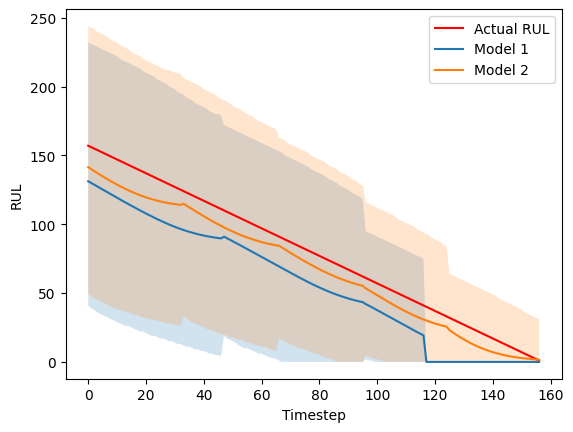

In [92]:
alpha = 0.005 # Confidence level used to generate the intervals
for cmd in data_train.values():
    actual_RUL = len(cmd)-np.arange(len(cmd))
    
    predictions = [
        predict_hsmm_bounds(cmd, model1,alpha = alpha ),
        predict_hsmm_bounds(cmd, model2,alpha = alpha ),
                   ]
    
    # Uncomment these lines to get the RUL plot
    plot_rul_bounds_multiple(actual_RUL,  predictions)
    break
    


Now, plot for the same trajectory, the baseline prognostics and the UM prognostics

Comment on the effect of the UM stategy. What did you observe in the metrics? Comment on the reliability of these prognsotics
Write your answer here:



...


## Task 5: Compute your prognostics for the training, validation and testing datasets



Compute the predictions with the baseline model (Task 2) and the UM model (Task 4)

In [ ]:
# Example on how to generate prognostics with a single model

# 1. Load the model
model = CustomHSMM(name = 'hsmm_exmple')
model.load_model('hsmm_exmple')

# 2. format the dataset
data_train, _ = format_data(df_train)

# 3.  Genrate the prognostics for each trajectory
predictions_train = []
for trajectory in data_train.values():
    predictions_train = predict_hsmm_pdf_staked(trajectory, model,predictions_train)
    
# 4. Save the prognostics
save_prognostics(predictions_train, 'train')


In [ ]:
# For validation
# 2. format the dataset
data_val, max_len = format_data(df_validation)

# 3.  Genrate the prognostics for each trajectory
predictions_val = []
for trajectory in data_val.values():
    predictions_val = predict_hsmm_pdf_staked(trajectory, model,predictions_val)
    
# 4. Save the prognostics
save_prognostics(predictions_val, 'validation')

In [ ]:
# For test
# 2. format the dataset
data_test, max_len = format_data(df_test)

# 3.  Genrate the prognostics for each trajectory
predictions_test = []
for trajectory in data_test.values():
    predictions_test = predict_hsmm_pdf_staked(trajectory, model,predictions_test)
    
# 4. Save the prognostics
save_prognostics(predictions_test, 'test')